In [1]:
import pandas as pd
df=pd.read_csv('data/clean_data/data_with_bertopic_column.csv')

In [4]:
user_item_sequence = (
    df.groupby('user_id')[['item_id']]
    .agg(list)
    .to_dict(orient='index')
)

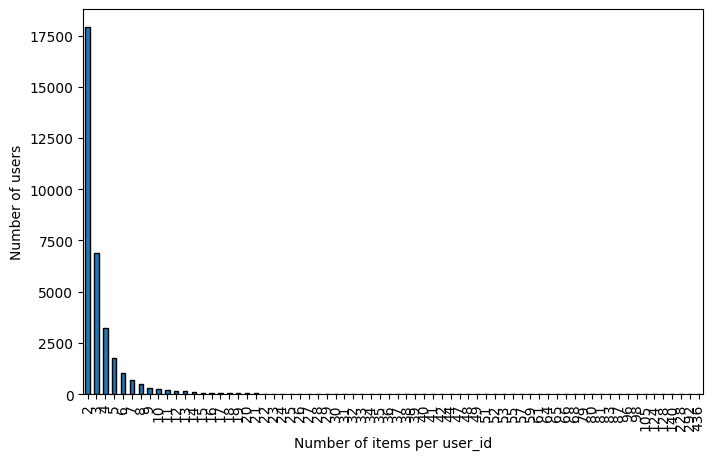

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

# Build df_counts
df_counts = pd.DataFrame([
    {"user_id": k, "count": len(v["item_id"])}
    for k, v in user_item_sequence.items()
])

# Filter out users with < 2 items
df_counts = df_counts[df_counts["count"] >= 2]

# Count frequency of each "count"
count_distribution = df_counts["count"].value_counts().sort_index()

# Plot bar chart
plt.figure(figsize=(8, 5))
count_distribution.plot(kind="bar", edgecolor="black")

plt.xlabel("Number of items per user_id")
plt.ylabel("Number of users")
plt.show()
